# Отчет NL2SQL: Synthetic E-commerce Benchmark

Аналитический notebook по результатам локального synthetic benchmark-сценария `synthetic_ecommerce`. Ниже рассматриваются агрегированные результаты режимов `ea` и `pass_k`, распределение качества по уровням сложности и поведение моделей на уровне отдельных запросов.


## 1. Подготовка и источники данных

В данном разделе задаются пути к synthetic-результатам, настраивается окружение для анализа и загружаются агрегированные и детализированные артефакты прогонов.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent):
    if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RESULTS_ROOT = PROJECT_ROOT / 'results' / 'nl2sql' / 'synthetic_benchmark'
EA_ROOT = RESULTS_ROOT
PASSK_ROOT = RESULTS_ROOT / 'pass_k'
FIGURES_DIR = RESULTS_ROOT / 'figures' / 'synthetic_analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_META = {
    'm1_deepseek': {'display_name': 'DeepSeek', 'model_group': 'M1'},
    'm1_chatgpt': {'display_name': 'ChatGPT', 'model_group': 'M1'},
    'm2_defog': {'display_name': 'Defog-Llama3-SQLCoder-8B', 'model_group': 'M2'},
    'm2_hrida': {'display_name': 'Hrida-T2SQL', 'model_group': 'M2'},
    'm2_arctic': {'display_name': 'Arctic-Text2SQL-R1-7B', 'model_group': 'M2'},
}

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

print(f'Project root: {PROJECT_ROOT}')
print(f'Results root: {RESULTS_ROOT}')
print(f'Figures dir: {FIGURES_DIR}')


Project root: /home/count/code/vkr
Results root: /home/count/code/vkr/results/nl2sql/synthetic_benchmark
Figures dir: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/synthetic_analysis


In [2]:
def load_json(path: Path):
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)


def iter_result_dirs(root: Path, mode: str):
    if mode == 'ea':
        dirs = [p for p in root.iterdir() if p.is_dir() and p.name not in {'pass_k', 'smoke', 'figures'}]
    else:
        dirs = [p for p in root.iterdir() if p.is_dir()]
    return sorted(dirs)


def build_summary_rows(result_dirs, mode: str):
    overall_rows = []
    difficulty_rows = []
    detailed_rows = []

    for result_dir in result_dirs:
        model_key = result_dir.name
        meta = MODEL_META.get(model_key, {'display_name': model_key, 'model_group': 'other'})
        results_path = result_dir / 'results.json'
        details_path = result_dir / 'detailed_results.json'
        if not results_path.exists() or not details_path.exists():
            continue

        summary = load_json(results_path)
        detailed = load_json(details_path)

        overall_row = {
            'model_key': model_key,
            'model_display_name': meta['display_name'],
            'model_group': meta['model_group'],
            'mode': mode,
            **summary['overall'],
            'n_samples': len(detailed),
        }
        overall_rows.append(overall_row)

        for difficulty, metrics in summary.get('by_difficulty', {}).items():
            difficulty_rows.append({
                'model_key': model_key,
                'model_display_name': meta['display_name'],
                'model_group': meta['model_group'],
                'mode': mode,
                'difficulty': difficulty,
                **metrics,
            })

        for sample_index, row in enumerate(detailed, start=1):
            candidate_results = row.get('candidate_results') or []
            detailed_rows.append({
                'model_key': model_key,
                'model_display_name': meta['display_name'],
                'model_group': meta['model_group'],
                'mode': mode,
                'sample_index': sample_index,
                'question': row.get('question'),
                'sql_gt': row.get('sql_gt'),
                'sql_pred': row.get('sql_pred'),
                'difficulty': row.get('difficulty'),
                'valid': bool(row.get('valid')),
                'execution_match': bool(row.get('execution_match')),
                'inference_error': row.get('inference_error'),
                'prediction_error': row.get('prediction_error'),
                'ground_truth_error': row.get('ground_truth_error'),
                'n_candidates': len(row.get('sql_candidates') or []),
                'n_valid_candidates': sum(1 for c in candidate_results if c.get('valid')),
                'n_matching_candidates': sum(1 for c in candidate_results if c.get('execution_match')),
                'any_candidate_match': any(c.get('execution_match') for c in candidate_results) if candidate_results else bool(row.get('execution_match')),
            })

    overall_df = pd.DataFrame(overall_rows)
    difficulty_df = pd.DataFrame(difficulty_rows)
    detailed_df = pd.DataFrame(detailed_rows)
    return overall_df, difficulty_df, detailed_df


ea_overall_df, ea_difficulty_df, ea_detail_df = build_summary_rows(iter_result_dirs(EA_ROOT, 'ea'), mode='ea')
passk_overall_df, passk_difficulty_df, passk_detail_df = build_summary_rows(iter_result_dirs(PASSK_ROOT, 'pass_k'), mode='pass_k')

pass_metric_cols = sorted(
    [col for col in passk_overall_df.columns if col.startswith('pass@') and '_ci_' not in col and '_q' not in col],
    key=lambda col: int(col.split('@', 1)[1]),
)

print('EA overall:', ea_overall_df.shape)
print('EA difficulty:', ea_difficulty_df.shape)
print('EA detail:', ea_detail_df.shape)
print('Pass@K overall:', passk_overall_df.shape)
print('Pass@K difficulty:', passk_difficulty_df.shape)
print('Pass@K detail:', passk_detail_df.shape)

display(ea_overall_df.sort_values(['model_group', 'model_display_name']).round(4))
display(passk_overall_df[['model_display_name', 'model_group', 'execution_accuracy', 'valid_sql_rate', *pass_metric_cols, 'n_samples']].sort_values(['model_group', 'model_display_name']).round(4))


EA overall: (5, 7)
EA difficulty: (15, 7)
EA detail: (150, 18)
Pass@K overall: (5, 25)
Pass@K difficulty: (15, 25)
Pass@K detail: (150, 18)


,model_key,model_display_name,model_group,mode,execution_accuracy,valid_sql_rate,n_samples
0,m1_chatgpt,ChatGPT,M1,ea,0.7000,0.8333,30
1,m1_deepseek,DeepSeek,M1,ea,0.8333,1.0000,30
2,m2_arctic,Arctic-Text2SQL-R1-7B,M2,ea,0.7333,1.0000,30
3,m2_defog,Defog-Llama3-SQLCoder-8B,M2,ea,0.6333,0.9000,30
4,m2_hrida,Hrida-T2SQL,M2,ea,0.7333,1.0000,30


,model_display_name,model_group,execution_accuracy,valid_sql_rate,pass@1,pass@3,pass@5,n_samples
0,ChatGPT,M1,0.7000,0.8333,0.7133,0.7333,0.7333,30
1,DeepSeek,M1,0.8333,1.0000,0.8133,0.8333,0.8333,30
2,Arctic-Text2SQL-R1-7B,M2,0.7667,0.9667,0.7733,0.8200,0.8333,30
3,Defog-Llama3-SQLCoder-8B,M2,0.5333,0.7667,0.5267,0.6600,0.7000,30
4,Hrida-T2SQL,M2,0.6333,0.8333,0.6133,0.7367,0.7667,30


## 2. Обзор доступных прогонов

Synthetic benchmark выполняется на фиксированном наборе запросов, поэтому на уровне обзора важно проверить полноту доступных прогонов, объем выборки и базовые характеристики самих benchmark-примеров.


,model_display_name,model_group,mode,n_samples
0,ChatGPT,M1,ea,30
1,DeepSeek,M1,ea,30
2,Arctic-Text2SQL-R1-7B,M2,ea,30
3,Defog-Llama3-SQLCoder-8B,M2,ea,30
4,Hrida-T2SQL,M2,ea,30
5,ChatGPT,M1,pass_k,30
6,DeepSeek,M1,pass_k,30
7,Arctic-Text2SQL-R1-7B,M2,pass_k,30
8,Defog-Llama3-SQLCoder-8B,M2,pass_k,30
9,Hrida-T2SQL,M2,pass_k,30


,difficulty,count
0,easy,10
1,medium,10
2,hard,10


,n_samples,mean_question_len,median_question_len,mean_gold_sql_len,median_gold_sql_len
0,30,143.33,130.5,221.07,205.0


/tmp/ipykernel_103852/3925001452.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_df, x='difficulty', order=['easy', 'medium', 'hard'], ax=axes[0], palette='Set2')


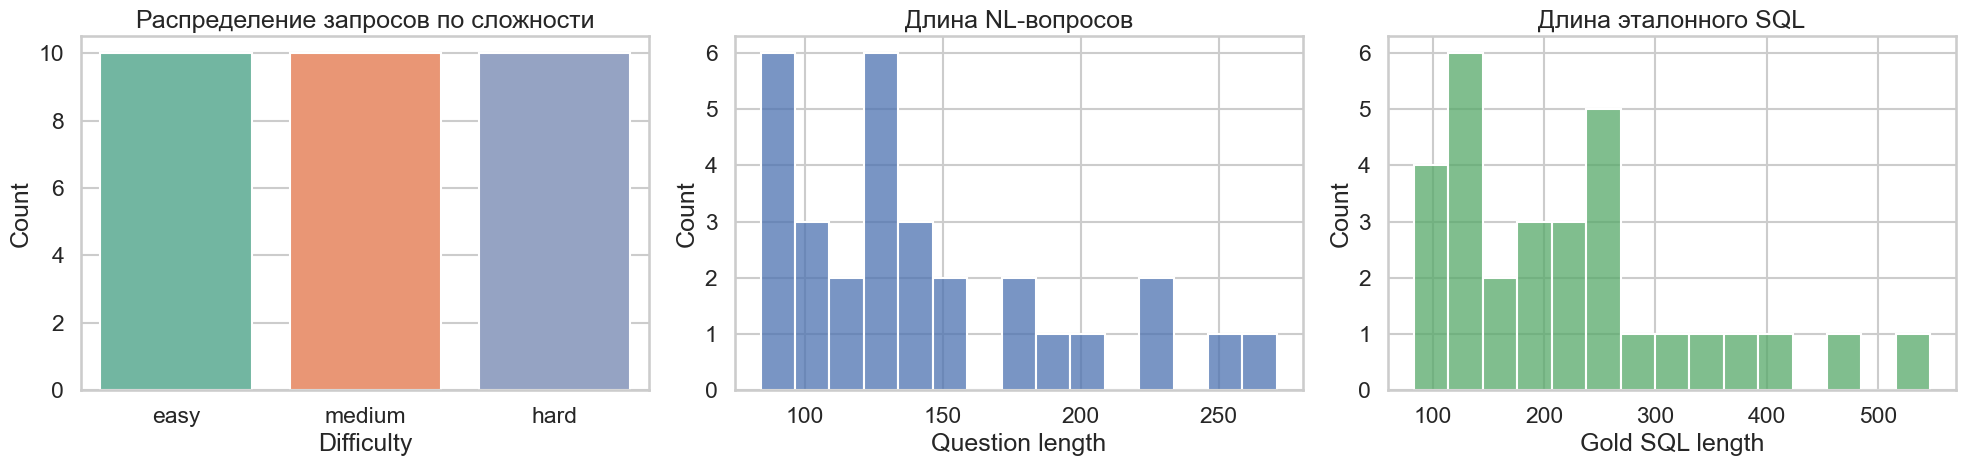

In [3]:
dataset_df = (
    ea_detail_df[['sample_index', 'question', 'sql_gt', 'difficulty']]
    .sort_values('sample_index')
    .drop_duplicates(subset=['sample_index'])
    .copy()
)
dataset_df['question_len'] = dataset_df['question'].str.len()
dataset_df['gold_sql_len'] = dataset_df['sql_gt'].str.len()

run_inventory_df = pd.concat([
    ea_overall_df[['model_display_name', 'model_group', 'mode', 'n_samples']],
    passk_overall_df[['model_display_name', 'model_group', 'mode', 'n_samples']],
], ignore_index=True).sort_values(['mode', 'model_group', 'model_display_name'])

dataset_overview_df = pd.DataFrame([
    {
        'n_samples': len(dataset_df),
        'mean_question_len': dataset_df['question_len'].mean(),
        'median_question_len': dataset_df['question_len'].median(),
        'mean_gold_sql_len': dataset_df['gold_sql_len'].mean(),
        'median_gold_sql_len': dataset_df['gold_sql_len'].median(),
    }
])

display(run_inventory_df)
display(dataset_df['difficulty'].value_counts().rename_axis('difficulty').reset_index(name='count'))
display(dataset_overview_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(data=dataset_df, x='difficulty', order=['easy', 'medium', 'hard'], ax=axes[0], palette='Set2')
axes[0].set_title('Распределение запросов по сложности')
axes[0].set_xlabel('Difficulty')
axes[0].set_ylabel('Count')

sns.histplot(data=dataset_df, x='question_len', bins=15, ax=axes[1], color='#4c72b0')
axes[1].set_title('Длина NL-вопросов')
axes[1].set_xlabel('Question length')

sns.histplot(data=dataset_df, x='gold_sql_len', bins=15, ax=axes[2], color='#55a868')
axes[2].set_title('Длина эталонного SQL')
axes[2].set_xlabel('Gold SQL length')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'synthetic_report_01_dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Основные результаты режима EA

В данном разделе рассматриваются single-shot результаты `ea`, то есть качество первого сгенерированного SQL-кандидата без многократных попыток генерации.


,model_display_name,model_group,execution_accuracy,valid_sql_rate,n_samples
1,DeepSeek,M1,0.8333,1.0000,30
0,ChatGPT,M1,0.7000,0.8333,30
2,Arctic-Text2SQL-R1-7B,M2,0.7333,1.0000,30
4,Hrida-T2SQL,M2,0.7333,1.0000,30
3,Defog-Llama3-SQLCoder-8B,M2,0.6333,0.9000,30


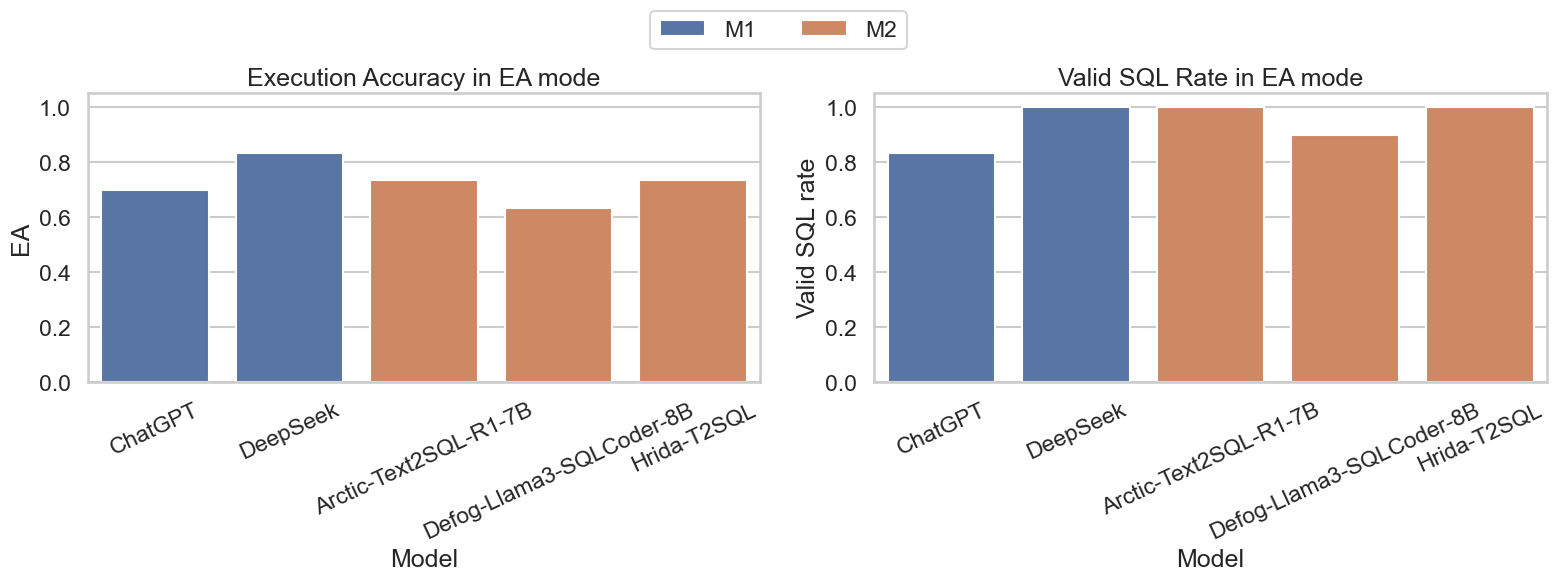

In [4]:
ea_main_df = ea_overall_df[['model_display_name', 'model_group', 'execution_accuracy', 'valid_sql_rate', 'n_samples']].sort_values(['model_group', 'execution_accuracy'], ascending=[True, False])
display(ea_main_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ea_overall_df, x='model_display_name', y='execution_accuracy', hue='model_group', dodge=False, ax=axes[0])
axes[0].set_title('Execution Accuracy in EA mode')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('EA')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=ea_overall_df, x='model_display_name', y='valid_sql_rate', hue='model_group', dodge=False, ax=axes[1])
axes[1].set_title('Valid SQL Rate in EA mode')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Valid SQL rate')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)

for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels))
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig(FIGURES_DIR / 'synthetic_report_02_ea_overall.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Разложение EA по уровням сложности

Поскольку benchmark содержит сбалансированное распределение `easy`, `medium` и `hard` запросов, отдельный анализ по сложности позволяет увидеть, в какой части набора происходит основное снижение качества.


difficulty,easy,medium,hard
model_display_name,,,
Arctic-Text2SQL-R1-7B,1.0,0.7,0.5
ChatGPT,0.8,0.7,0.6
DeepSeek,1.0,0.8,0.7
Defog-Llama3-SQLCoder-8B,1.0,0.7,0.2
Hrida-T2SQL,1.0,0.8,0.4


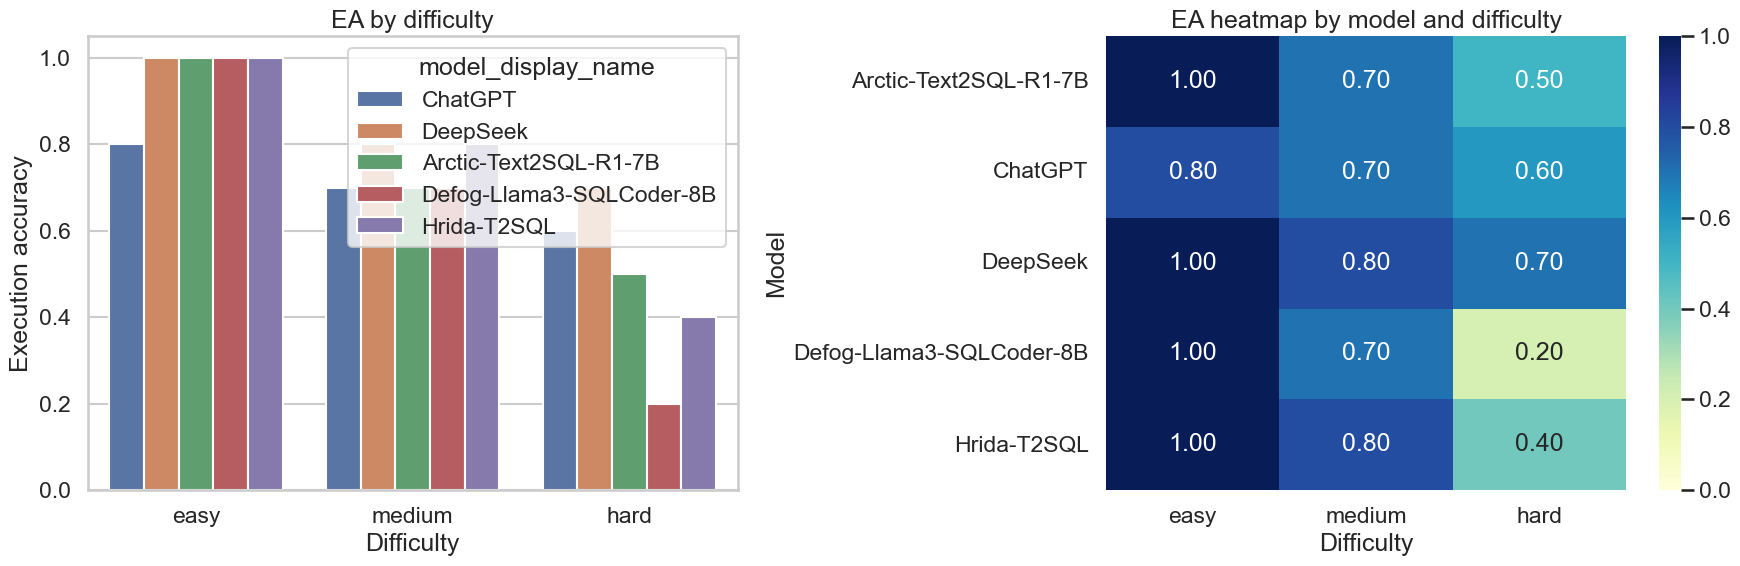

In [5]:
ea_difficulty_pivot = ea_difficulty_df.pivot(index='model_display_name', columns='difficulty', values='execution_accuracy')[['easy', 'medium', 'hard']]
display(ea_difficulty_pivot.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=ea_difficulty_df,
    x='difficulty',
    y='execution_accuracy',
    hue='model_display_name',
    order=['easy', 'medium', 'hard'],
    ax=axes[0],
)
axes[0].set_title('EA by difficulty')
axes[0].set_xlabel('Difficulty')
axes[0].set_ylabel('Execution accuracy')
axes[0].set_ylim(0, 1.05)

sns.heatmap(ea_difficulty_pivot, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('EA heatmap by model and difficulty')
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'synthetic_report_03_ea_by_difficulty.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Основные результаты режима Pass@K

EA используется как базовая single-shot оценка качества. Метрика Pass@K показывает вероятность получить хотя бы один корректный SQL-запрос среди K независимых попыток генерации, поэтому ниже она показана как зависимость качества от числа попыток, а не как однородная категория рядом с EA.


,model_display_name,model_group,execution_accuracy,valid_sql_rate,pass@1,pass@3,pass@5,n_samples
0,ChatGPT,M1,0.7000,0.8333,0.7133,0.7333,0.7333,30
1,DeepSeek,M1,0.8333,1.0000,0.8133,0.8333,0.8333,30
2,Arctic-Text2SQL-R1-7B,M2,0.7667,0.9667,0.7733,0.8200,0.8333,30
3,Defog-Llama3-SQLCoder-8B,M2,0.5333,0.7667,0.5267,0.6600,0.7000,30
4,Hrida-T2SQL,M2,0.6333,0.8333,0.6133,0.7367,0.7667,30


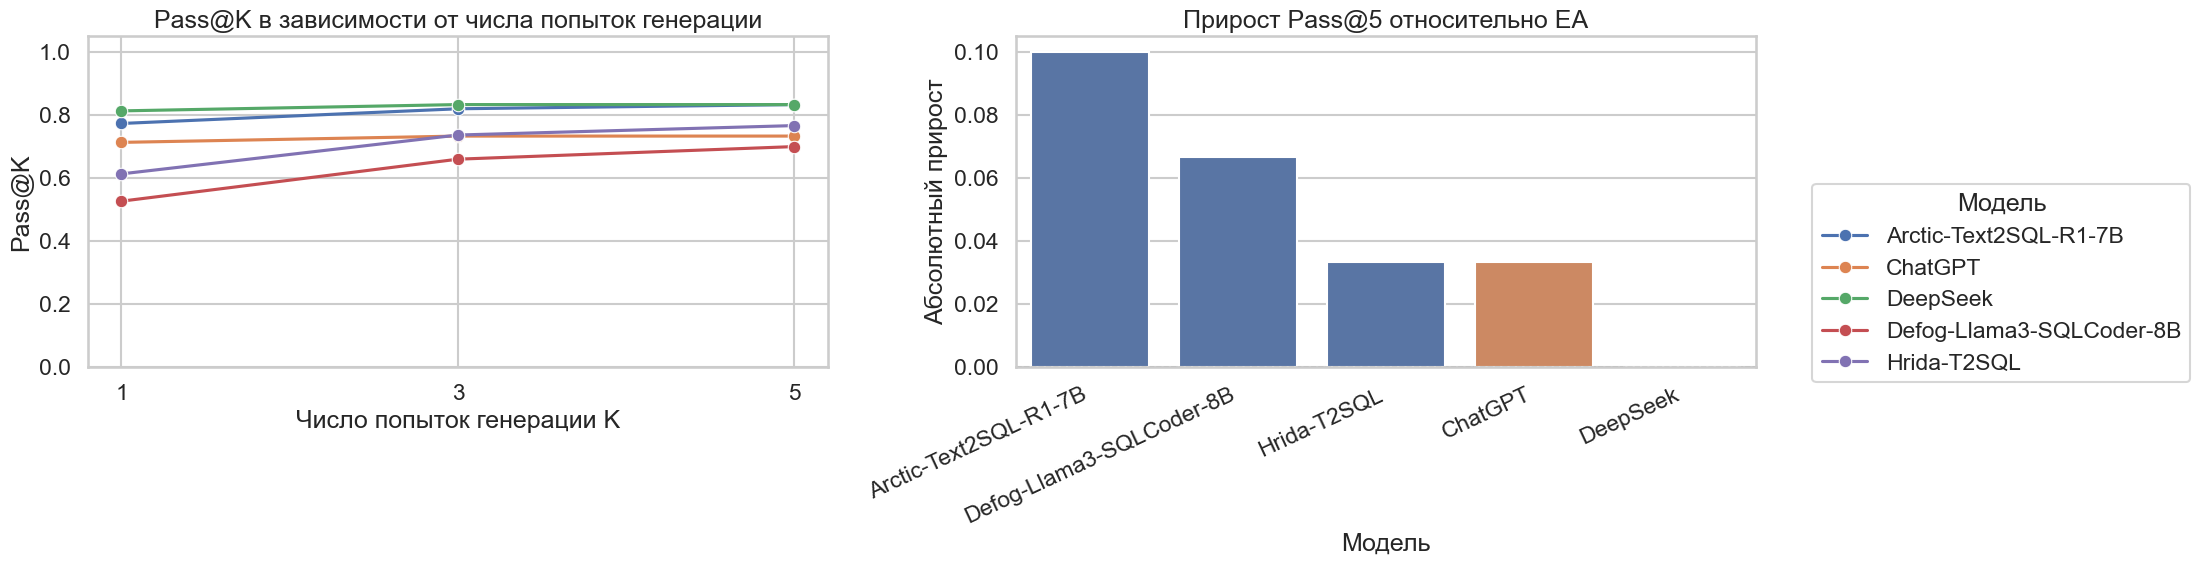

Сохранён рисунок 3.5: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/figure_3_5_seb_passk_and_gain_ru.png


In [6]:
METRIC_LABELS = {
    'execution_accuracy': 'Execution Accuracy',
    'valid_sql_rate': 'Доля исполнимых SQL',
    'pass@1': 'Pass@1',
    'pass@3': 'Pass@3',
    'pass@5': 'Pass@5',
}

passk_main_cols = ['model_display_name', 'model_group', 'execution_accuracy', 'valid_sql_rate', *pass_metric_cols, 'n_samples']
display(passk_overall_df[passk_main_cols].sort_values(['model_group', 'model_display_name']).round(4))

passk_curve_df = passk_overall_df.melt(
    id_vars=['model_key', 'model_display_name', 'model_group'],
    value_vars=pass_metric_cols,
    var_name='metric',
    value_name='score',
).copy()
passk_curve_df['metric_ru'] = passk_curve_df['metric'].map(METRIC_LABELS).fillna(passk_curve_df['metric'])
passk_curve_df['k'] = passk_curve_df['metric'].str.extract(r'pass@(\d+)').astype(int)

ea_vs_passk_df = ea_overall_df[['model_key', 'model_display_name', 'model_group', 'execution_accuracy']].merge(
    passk_overall_df[['model_key', *pass_metric_cols]],
    on='model_key',
    how='inner',
)
for metric in pass_metric_cols:
    ea_vs_passk_df[f'{metric}_gain_vs_ea'] = ea_vs_passk_df[metric] - ea_vs_passk_df['execution_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=passk_curve_df.sort_values(['model_display_name', 'k']),
    x='k',
    y='score',
    hue='model_display_name',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('Pass@K в зависимости от числа попыток генерации')
axes[0].set_xlabel('Число попыток генерации K')
axes[0].set_ylabel('Pass@K')
axes[0].set_xticks(sorted(passk_curve_df['k'].unique()))
axes[0].set_ylim(0, 1.05)
if axes[0].legend_ is not None:
    axes[0].legend_.remove()

final_metric = pass_metric_cols[-1] if pass_metric_cols else None
if final_metric:
    gain_col = f'{final_metric}_gain_vs_ea'
    gain_df = ea_vs_passk_df[['model_display_name', 'model_group', gain_col]].sort_values(gain_col, ascending=False)
    sns.barplot(data=gain_df, x='model_display_name', y=gain_col, hue='model_group', dodge=False, ax=axes[1])
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title(f'Прирост {METRIC_LABELS.get(final_metric, final_metric)} относительно EA')
    axes[1].set_xlabel('Модель')
    axes[1].set_ylabel('Абсолютный прирост')
    axes[1].tick_params(axis='x', rotation=25)
    for label in axes[1].get_xticklabels():
        label.set_horizontalalignment('right')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Нет Pass@K-метрик', ha='center', va='center')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Модель', bbox_to_anchor=(1.01, 0.5), loc='center left')
fig.tight_layout()
figure_path = FIGURES_DIR / 'figure_3_5_seb_passk_and_gain_ru.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён рисунок 3.5: {figure_path}')


## 6. Прирост от многократной генерации

Ниже сопоставляются результаты `ea` и `pass_k` для одних и тех же моделей. Такой анализ показывает, насколько наличие нескольких кандидатов компенсирует ошибки первого ответа и где эффект от многократной генерации выражен сильнее.


,model_key,model_display_name,model_group,execution_accuracy,pass@1,pass@3,pass@5,pass@1_gain_vs_ea,pass@3_gain_vs_ea,pass@5_gain_vs_ea
0,m1_chatgpt,ChatGPT,M1,0.7000,0.7133,0.7333,0.7333,0.0133,0.0333,0.0333
1,m1_deepseek,DeepSeek,M1,0.8333,0.8133,0.8333,0.8333,-0.0200,0.0000,0.0000
2,m2_arctic,Arctic-Text2SQL-R1-7B,M2,0.7333,0.7733,0.8200,0.8333,0.0400,0.0867,0.1000
3,m2_defog,Defog-Llama3-SQLCoder-8B,M2,0.6333,0.5267,0.6600,0.7000,-0.1067,0.0267,0.0667
4,m2_hrida,Hrida-T2SQL,M2,0.7333,0.6133,0.7367,0.7667,-0.1200,0.0033,0.0333


difficulty_ru,простые,средние,сложные
model_display_name,,,
Arctic-Text2SQL-R1-7B,1.0,0.8,0.7
ChatGPT,0.8,0.7,0.7
DeepSeek,1.0,0.8,0.7
Defog-Llama3-SQLCoder-8B,1.0,0.7,0.4
Hrida-T2SQL,1.0,0.8,0.5


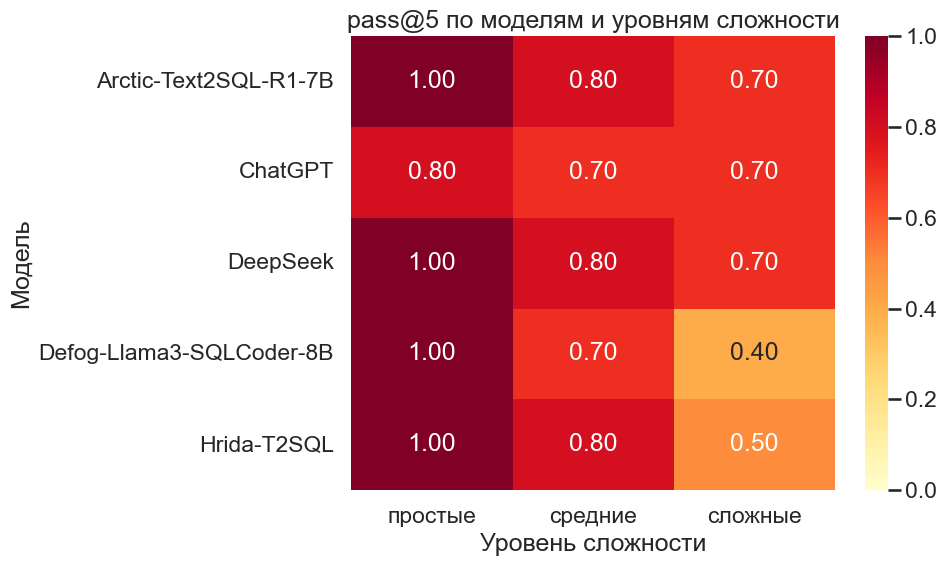

Сохранён дополнительный рисунок Pass@K по сложности: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/synthetic_analysis/synthetic_report_06_passk_by_difficulty.png


In [7]:
if 'ea_vs_passk_df' not in globals():
    ea_vs_passk_df = ea_overall_df[['model_key', 'model_display_name', 'model_group', 'execution_accuracy']].merge(
        passk_overall_df[['model_key', *pass_metric_cols]],
        on='model_key',
        how='inner',
    )
    for metric in pass_metric_cols:
        ea_vs_passk_df[f'{metric}_gain_vs_ea'] = ea_vs_passk_df[metric] - ea_vs_passk_df['execution_accuracy']

display(ea_vs_passk_df.sort_values(['model_group', 'model_display_name']).round(4))

DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
passk_difficulty_metric = pass_metric_cols[-1] if pass_metric_cols else 'execution_accuracy'
passk_difficulty_plot_df = passk_difficulty_df.copy()
passk_difficulty_plot_df['difficulty_ru'] = passk_difficulty_plot_df['difficulty'].map(DIFFICULTY_LABELS).fillna(passk_difficulty_plot_df['difficulty'])
passk_difficulty_pivot = (
    passk_difficulty_plot_df
    .pivot(index='model_display_name', columns='difficulty_ru', values=passk_difficulty_metric)
    .reindex(columns=['простые', 'средние', 'сложные'])
)
display(passk_difficulty_pivot.round(4))

plt.figure(figsize=(10, 6))
sns.heatmap(passk_difficulty_pivot, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title(f'{passk_difficulty_metric} по моделям и уровням сложности')
plt.xlabel('Уровень сложности')
plt.ylabel('Модель')
plt.tight_layout()
figure_path = FIGURES_DIR / 'synthetic_report_06_passk_by_difficulty.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён дополнительный рисунок Pass@K по сложности: {figure_path}')


## 7. Анализ ошибок на уровне запросов

Завершающий раздел фиксирует распределение ошибок по моделям и выделяет запросы, которые вызывают наибольшие затруднения. Для `pass_k` дополнительно оценивается, в скольких случаях наличие нескольких кандидатов позволило восстановить корректный результат.


In [8]:
ea_error_summary_df = ea_detail_df.groupby(['model_display_name', 'difficulty']).agg(
    total=('sample_index', 'count'),
    valid_sql=('valid', 'sum'),
    execution_match=('execution_match', 'sum'),
).reset_index()
ea_error_summary_df['invalid_sql'] = ea_error_summary_df['total'] - ea_error_summary_df['valid_sql']
ea_error_summary_df['misses'] = ea_error_summary_df['total'] - ea_error_summary_df['execution_match']
display(ea_error_summary_df.sort_values(['model_display_name', 'difficulty']))

hardest_queries_df = (
    ea_detail_df.groupby(['sample_index', 'difficulty', 'question'])
    .agg(models_solved=('execution_match', 'sum'), n_models=('model_key', 'nunique'))
    .reset_index()
)
hardest_queries_df['solve_rate'] = hardest_queries_df['models_solved'] / hardest_queries_df['n_models']
display(hardest_queries_df.sort_values(['solve_rate', 'difficulty', 'sample_index']).head(10))

recovery_df = passk_detail_df[['model_key', 'model_display_name', 'sample_index', 'difficulty', 'execution_match', 'any_candidate_match']].merge(
    ea_detail_df[['model_key', 'sample_index', 'execution_match']].rename(columns={'execution_match': 'ea_execution_match'}),
    on=['model_key', 'sample_index'],
    how='left',
)
recovery_df['recovered_in_passk'] = (~recovery_df['ea_execution_match']) & (recovery_df['any_candidate_match'])

recovery_summary_df = recovery_df.groupby('model_display_name').agg(
    recovered_cases=('recovered_in_passk', 'sum'),
    total_samples=('sample_index', 'count'),
    passk_any_hit=('any_candidate_match', 'mean'),
).reset_index().sort_values('recovered_cases', ascending=False)
display(recovery_summary_df.round(4))

recovered_examples_df = recovery_df[recovery_df['recovered_in_passk']].merge(
    passk_detail_df[['model_key', 'sample_index', 'question', 'sql_gt', 'sql_pred', 'n_matching_candidates']],
    on=['model_key', 'sample_index'],
    how='left',
)
display(recovered_examples_df[['model_display_name', 'difficulty', 'sample_index', 'n_matching_candidates', 'question']].head(15))


,model_display_name,difficulty,total,valid_sql,execution_match,invalid_sql,misses
0,Arctic-Text2SQL-R1-7B,easy,10,10,10,0,0
1,Arctic-Text2SQL-R1-7B,hard,10,10,5,0,5
2,Arctic-Text2SQL-R1-7B,medium,10,10,7,0,3
3,ChatGPT,easy,10,8,8,2,2
4,ChatGPT,hard,10,8,6,2,4
5,ChatGPT,medium,10,9,7,1,3
6,DeepSeek,easy,10,10,10,0,0
7,DeepSeek,hard,10,10,7,0,3
8,DeepSeek,medium,10,10,8,0,2
9,Defog-Llama3-SQLCoder-8B,easy,10,10,10,0,0


,sample_index,difficulty,question,models_solved,n_models,solve_rate
20,21,hard,"for each COALESCE(category_name, category_name), compute sum of quantity times unit_price - discount_amount by joini...",0,5,0.0
26,27,hard,"for each customer_segment, compute sum of CASE WHEN return_id IS NOT NULL THEN 1 ELSE 0 END by joining customers, or...",0,5,0.0
12,13,medium,"for each customer_id, first_name, and last_name, compute sum of total_amount by joining customers and orders",0,5,0.0
16,17,medium,"for each product_id and product_name, compute sum of quantity by joining products and order_items",0,5,0.0
22,23,hard,find product_id and product_name from the products table that do not have returned order items,1,5,0.2
27,28,hard,"find product_id, product_name, and unit_price by joining products and order_items where unit_price is greater than (...",1,5,0.2
25,26,hard,"for each order_id and total_amount, compute sum of quantity times unit_price - discount_amount by joining orders and...",2,5,0.4
28,29,hard,"find customer_id, first_name, and last_name from the customers table that have orders and do not have returned order...",2,5,0.4
14,15,medium,"for each brand, compute sum of quantity times unit_price - discount_amount by joining products and order_items",3,5,0.6
2,3,easy,"find customer_id, email, and customer_segment from the customers table where signup_date is at least 2024-01-01 and ...",4,5,0.8


,model_display_name,recovered_cases,total_samples,passk_any_hit
0,Arctic-Text2SQL-R1-7B,3,30,0.8333
3,Defog-Llama3-SQLCoder-8B,2,30,0.7000
1,ChatGPT,1,30,0.7333
4,Hrida-T2SQL,1,30,0.7667
2,DeepSeek,0,30,0.8333


,model_display_name,difficulty,sample_index,n_matching_candidates,question
0,ChatGPT,hard,23,4,find product_id and product_name from the products table that do not have returned order items
1,Arctic-Text2SQL-R1-7B,medium,15,1,"for each brand, compute sum of quantity times unit_price - discount_amount by joining products and order_items"
2,Arctic-Text2SQL-R1-7B,hard,23,4,find product_id and product_name from the products table that do not have returned order items
3,Arctic-Text2SQL-R1-7B,hard,26,3,"for each order_id and total_amount, compute sum of quantity times unit_price - discount_amount by joining orders and..."
4,Defog-Llama3-SQLCoder-8B,hard,22,1,"for each customer_id, first_name, and last_name, compute sum of total_amount by joining customers and orders where S..."
5,Defog-Llama3-SQLCoder-8B,hard,23,2,find product_id and product_name from the products table that do not have returned order items
6,Hrida-T2SQL,hard,23,1,find product_id and product_name from the products table that do not have returned order items
